In [4]:
from google.colab import files
uploaded = files.upload()

Saving World_Energy_Consumption (1).csv to World_Energy_Consumption (1).csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

!pip install pmdarima --quiet

from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)

DATA_PATH = 'World_Energy_Consumption.csv'
TARGET         = 'renewables_share_energy'
YEAR_START     = 1990
YEAR_END       = 2022
TRAIN_CUTOFF   = 2018
FORECAST_YEARS = 8

COUNTRIES = ['Brazil', 'Norway', 'United States', 'Morocco', 'Poland']

COLORS = {
    'Brazil':        '#2ecc71',
    'Norway':        '#3498db',
    'United States': '#e74c3c',
    'Morocco':       '#e67e22',
    'Poland':        '#9b59b6',
}

MLP_RESIDUALS = {
    'Brazil':        +23.9,
    'Norway':        +14.7,
    'United States': +6.5,
    'Morocco':       -28.2,
    'Poland':        -25.1,
}

In [12]:
df = pd.read_csv(DATA_PATH)

df_panel = df[
    df['country'].isin(COUNTRIES) &
    df['iso_code'].notna() &
    (df['iso_code'].str.len() == 3) &
    (df['year'] >= YEAR_START) &
    (df['year'] <= YEAR_END)
][['country', 'year', TARGET]].dropna().reset_index(drop=True)

print('Data coverage per country:')
print(f'{"Country":<20} {"Years":<8} {"Min%":<8} {"Max%"}')
print('-' * 48)
for c in COUNTRIES:
    sub = df_panel[df_panel['country'] == c]
    print(f'{c:<20} {len(sub):<8} {sub[TARGET].min():<8.1f} {sub[TARGET].max():.1f}')

Data coverage per country:
Country              Years    Min%     Max%
------------------------------------------------
Brazil               33       38.6     48.7
Norway               33       63.8     72.4
United States        33       3.4      11.3
Morocco              33       1.4      7.6
Poland               33       0.4      9.4


In [13]:
print('Augmented Dickey-Fuller Test Results')
print(f'{"Country":<20} {"ADF Stat":<12} {"p-value":<12} {"Stationary?"}')
print('-' * 58)

for c in COUNTRIES:
    series = df_panel[df_panel['country'] == c][TARGET].values
    adf_stat, p_val = adfuller(series, autolag='AIC')[:2]
    stationary = 'Yes' if p_val < 0.05 else 'No — differencing needed'
    print(f'{c:<20} {adf_stat:<12.3f} {p_val:<12.4f} {stationary}')

Augmented Dickey-Fuller Test Results
Country              ADF Stat     p-value      Stationary?
----------------------------------------------------------
Brazil               -1.688       0.4375       No — differencing needed
Norway               -3.740       0.0036       Yes
United States        1.890        0.9985       No — differencing needed
Morocco              0.306        0.9776       No — differencing needed
Poland               2.685        0.9991       No — differencing needed


In [14]:
models     = {}
forecasts  = {}
test_preds = {}

print('ARIMA Model Selection and Test Performance')
print(f'{"Country":<20} {"Order":<14} {"AIC":<10} {"Test RMSE (pp)"}')
print('-' * 58)

for c in COUNTRIES:
    sub  = df_panel[df_panel['country'] == c].sort_values('year')
    vals = sub[TARGET].values

    train_mask = sub['year'].values <= TRAIN_CUTOFF
    train_vals = vals[train_mask]
    test_vals  = vals[~train_mask]
    test_years = sub['year'].values[~train_mask]
    n_test     = len(test_vals)

    model = auto_arima(
        train_vals,
        seasonal=False,
        stepwise=True,
        max_p=3, max_q=3, max_d=2,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True,
    )

    test_pred = model.predict(n_periods=n_test)
    test_rmse = np.sqrt(np.mean((test_vals - test_pred) ** 2))

    order       = model.order
    final_model = ARIMA(vals, order=order).fit()
    fc_result   = final_model.get_forecast(steps=FORECAST_YEARS)
    fc_mean     = np.clip(fc_result.predicted_mean, 0, 100)
    fc_ci       = np.clip(fc_result.conf_int(alpha=0.05), 0, 100)

    models[c]     = final_model
    test_preds[c] = (test_vals, test_pred, test_years)
    forecasts[c]  = {
        'years':     np.arange(YEAR_END + 1, YEAR_END + 1 + FORECAST_YEARS),
        'mean':      fc_mean,
        'lower':     fc_ci[:, 0],
        'upper':     fc_ci[:, 1],
        'order':     order,
        'aic':       final_model.aic,
        'test_rmse': test_rmse,
    }

    print(f'{c:<20} ARIMA{str(order):<14} {final_model.aic:<10.1f} {test_rmse:.2f}')

ARIMA Model Selection and Test Performance
Country              Order          AIC        Test RMSE (pp)
----------------------------------------------------------
Brazil               ARIMA(1, 0, 0)      134.0      3.41
Norway               ARIMA(1, 0, 0)      149.6      2.66
United States        ARIMA(0, 2, 1)      44.6       0.75
Morocco              ARIMA(1, 0, 0)      113.9      2.57
Poland               ARIMA(0, 1, 3)      40.4       2.92


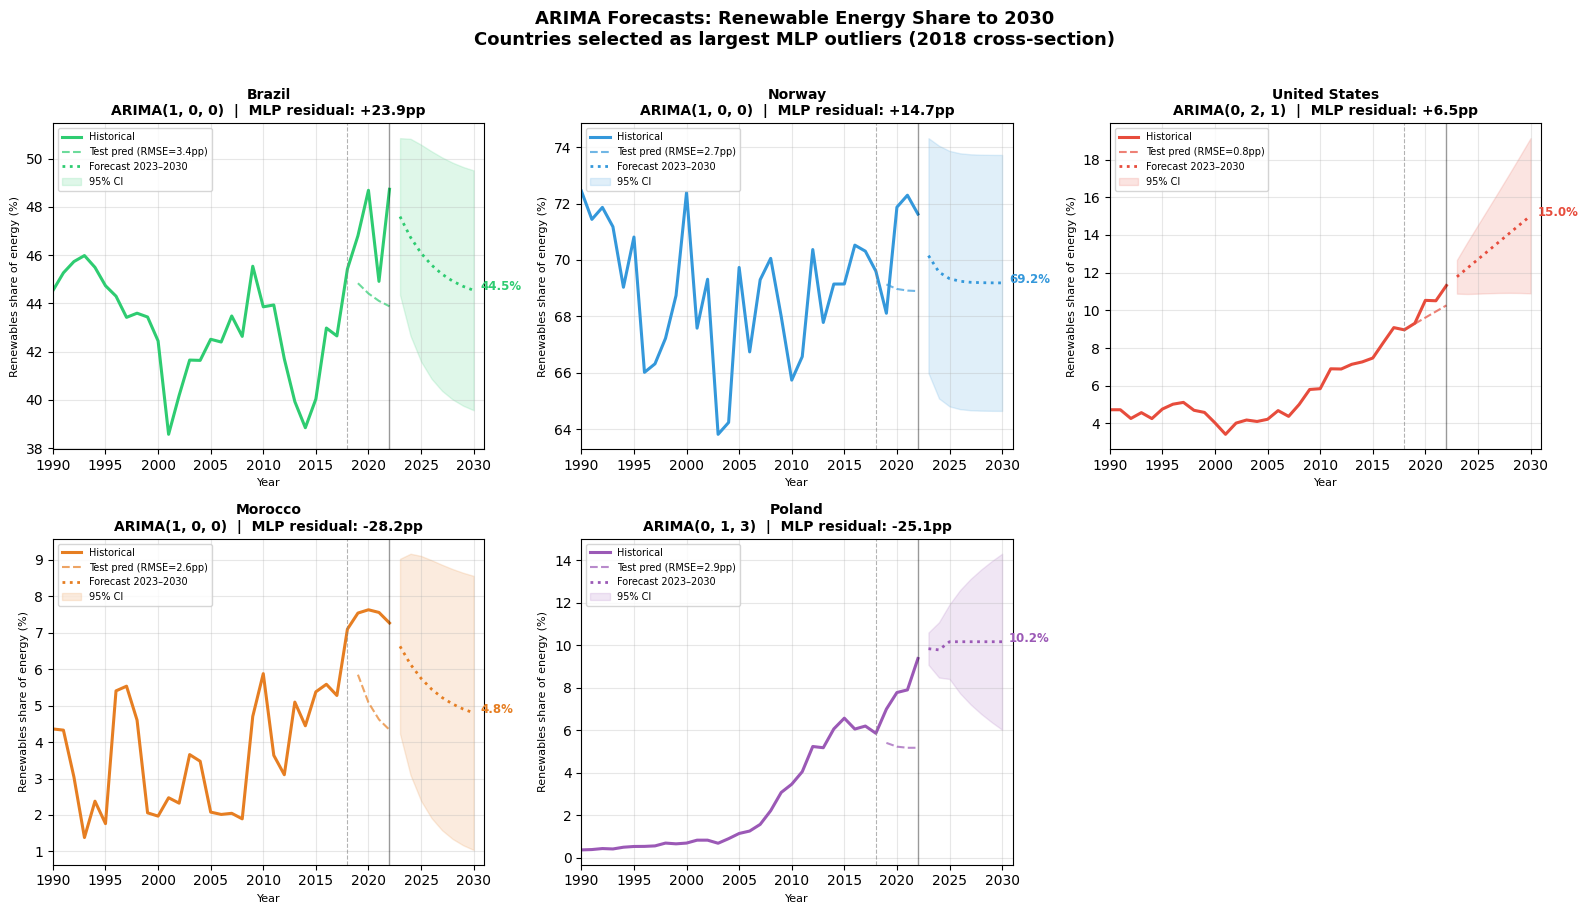

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, c in enumerate(COUNTRIES):
    ax  = axes[i]
    sub = df_panel[df_panel['country'] == c].sort_values('year')
    col = COLORS[c]
    fc  = forecasts[c]
    resid_val = MLP_RESIDUALS[c]
    resid_str = f'+{resid_val:.1f}pp' if resid_val > 0 else f'{resid_val:.1f}pp'

    ax.plot(sub['year'], sub[TARGET], color=col, linewidth=2.2, label='Historical')

    test_actual, test_pred, test_years = test_preds[c]
    ax.plot(test_years, test_pred, color=col, linewidth=1.5,
            linestyle='--', alpha=0.7, label=f'Test pred (RMSE={fc["test_rmse"]:.1f}pp)')

    ax.plot(fc['years'], fc['mean'], color=col, linewidth=2,
            linestyle=':', label='Forecast 2023–2030')
    ax.fill_between(fc['years'], fc['lower'], fc['upper'],
                    color=col, alpha=0.15, label='95% CI')

    ax.axvline(TRAIN_CUTOFF, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axvline(YEAR_END, color='black', linewidth=1, alpha=0.4)

    ax.annotate(f'{fc["mean"][-1]:.1f}%',
                xy=(fc['years'][-1], fc['mean'][-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8.5, color=col, fontweight='bold')

    ax.set_title(f'{c}\nARIMA{fc["order"]}  |  MLP residual: {resid_str}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Renewables share of energy (%)', fontsize=8)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(YEAR_START, 2031)

axes[5].set_visible(False)
fig.suptitle('ARIMA Forecasts: Renewable Energy Share to 2030\n'
             'Countries selected as largest MLP outliers (2018 cross-section)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_individual_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

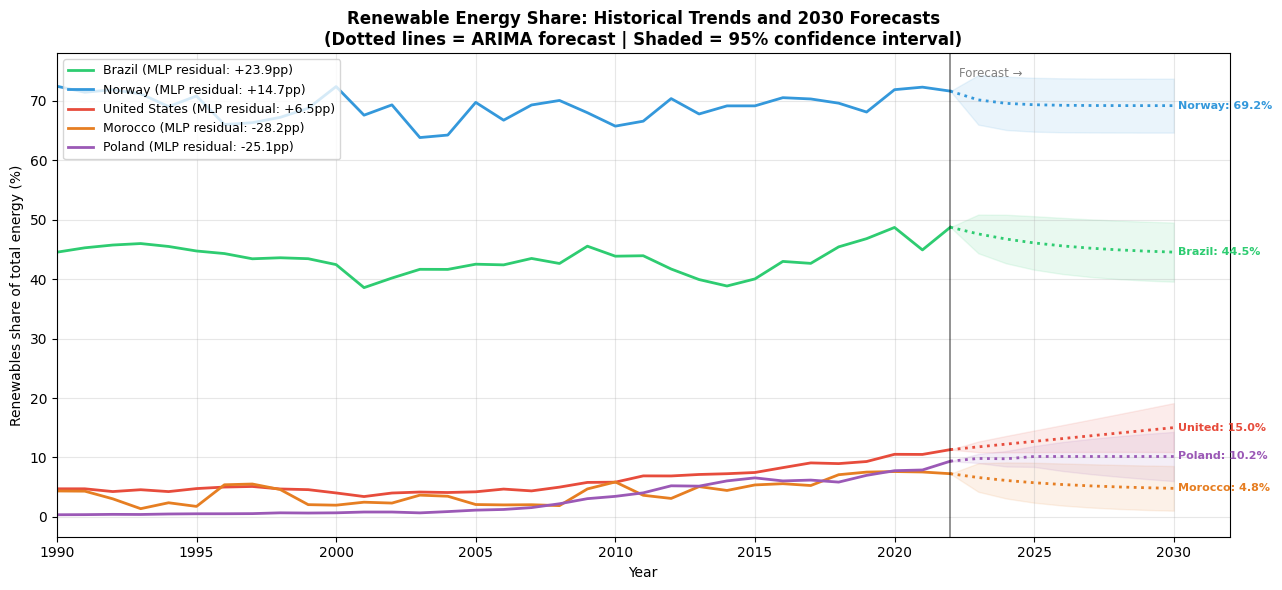

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))

for c in COUNTRIES:
    sub = df_panel[df_panel['country'] == c].sort_values('year')
    col = COLORS[c]
    fc  = forecasts[c]
    resid_val = MLP_RESIDUALS[c]
    resid_str = f'+{resid_val:.1f}pp' if resid_val > 0 else f'{resid_val:.1f}pp'

    ax.plot(sub['year'], sub[TARGET], color=col, linewidth=2,
            label=f'{c} (MLP residual: {resid_str})')

    fc_years_full = np.concatenate([[YEAR_END], fc['years']])
    fc_mean_full  = np.concatenate([[sub[TARGET].values[-1]], fc['mean']])
    fc_lower_full = np.concatenate([[sub[TARGET].values[-1]], fc['lower']])
    fc_upper_full = np.concatenate([[sub[TARGET].values[-1]], fc['upper']])

    ax.plot(fc_years_full, fc_mean_full, color=col, linewidth=2, linestyle=':')
    ax.fill_between(fc_years_full, fc_lower_full, fc_upper_full,
                    color=col, alpha=0.10)

    ax.annotate(f'{c.split()[0]}: {fc["mean"][-1]:.1f}%',
                xy=(2030, fc['mean'][-1]),
                xytext=(3, 0), textcoords='offset points',
                fontsize=8, color=col, fontweight='bold', va='center')

ax.axvline(YEAR_END, color='black', linewidth=1.2, alpha=0.5)
ax.text(YEAR_END + 0.3, ax.get_ylim()[1] * 0.97, 'Forecast →',
        fontsize=8.5, color='gray', va='top')

ax.set_title('Renewable Energy Share: Historical Trends and 2030 Forecasts\n'
             '(Dotted lines = ARIMA forecast | Shaded = 95% confidence interval)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Renewables share of total energy (%)', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(YEAR_START, 2032)

plt.tight_layout()
plt.savefig('arima_combined_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print('=' * 72)
print('ARIMA RESULTS SUMMARY')
print('=' * 72)
print(f'{"Country":<20} {"Order":<12} {"2022 Actual":<14} {"2030 Forecast":<16} {"Test RMSE"}')
print('-' * 72)

for c in COUNTRIES:
    sub         = df_panel[df_panel['country'] == c].sort_values('year')
    actual_2022 = sub[TARGET].values[-1]
    fc          = forecasts[c]
    fc_2030     = fc['mean'][-1]
    change      = fc_2030 - actual_2022
    change_str  = f'+{change:.1f}pp' if change >= 0 else f'{change:.1f}pp'
    print(f'{c:<20} ARIMA{str(fc["order"]):<12} {actual_2022:<14.1f} '
          f'{fc_2030:.1f}% ({change_str})    {fc["test_rmse"]:.2f}pp')

ARIMA RESULTS SUMMARY
Country              Order        2022 Actual    2030 Forecast    Test RMSE
------------------------------------------------------------------------
Brazil               ARIMA(1, 0, 0)    48.7           44.5% (-4.2pp)    3.41pp
Norway               ARIMA(1, 0, 0)    71.6           69.2% (-2.4pp)    2.66pp
United States        ARIMA(0, 2, 1)    11.3           15.0% (+3.7pp)    0.75pp
Morocco              ARIMA(1, 0, 0)    7.3            4.8% (-2.5pp)    2.57pp
Poland               ARIMA(0, 1, 3)    9.4            10.2% (+0.8pp)    2.92pp
